In [1]:
import urllib.request
import os

model_url = "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite"
model_path = "face_detector.tflite"

if not os.path.exists(model_path):
    print("Downloading face detector model...")
    urllib.request.urlretrieve(model_url, model_path)
    print("Download complete!")
else:
    print("Model already exists.")

Model already exists.


------------------------------
FACE PIXEL DATA
------------------------------
Dimensions (Height, Width, Channels): (1173, 1077, 3)
Data Type: uint8

Raw Pixel Array (First 3 rows shown):
[[[217 228 222]
  [217 228 220]
  [217 228 220]
  ...
  [220 230 222]
  [220 230 222]
  [220 230 222]]

 [[218 229 223]
  [218 229 221]
  [217 228 220]
  ...
  [220 230 222]
  [220 230 222]
  [220 230 222]]

 [[218 229 223]
  [218 229 221]
  [218 229 221]
  ...
  [220 230 222]
  [220 230 222]
  [220 230 222]]]
------------------------------


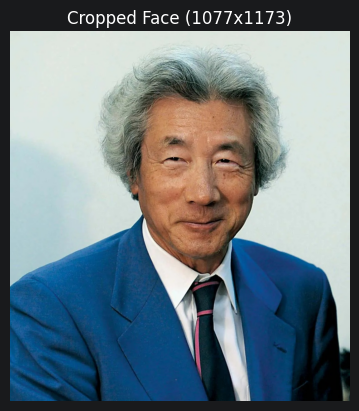

In [2]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2
import matplotlib.pyplot as plt
import numpy as np

base_options = python.BaseOptions(model_asset_path='face_detector.tflite')
options = vision.FaceDetectorOptions(base_options=base_options)
detector = vision.FaceDetector.create_from_options(options)

def get_face_crop_modern(img_path, zoom_out_factor=0.3):
    image_bgr = cv2.imread(img_path)
    if image_bgr is None:
        print("Error: Image not found.")
        return None

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    h_img, w_img, _ = image_rgb.shape

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = detector.detect(mp_image)

    if not detection_result.detections:
        print("No face detected.")
        return image_rgb

    # 1. Bounding Box & Zoom Logic
    bbox = detection_result.detections[0].bounding_box
    x, y, w, h = bbox.origin_x, bbox.origin_y, bbox.width, bbox.height

    dw, dh = int(w * zoom_out_factor), int(h * zoom_out_factor)

    new_x = max(0, x - dw)
    new_y = max(0, y - dh)
    new_w = min(w_img - new_x, w + (2 * dw))
    new_h = min(h_img - new_y, h + (2 * dh))

    # 2. Perform the Crop
    face_crop = image_rgb[new_y:new_y+new_h, new_x:new_x+new_w]

    # --- NEW: PRINT PIXEL DATA ---
    print("-" * 30)
    print(f"FACE PIXEL DATA")
    print("-" * 30)
    print(f"Dimensions (Height, Width, Channels): {face_crop.shape}")
    print(f"Data Type: {face_crop.dtype}")
    print("\nRaw Pixel Array (First 3 rows shown):")
    # We use [:3] to avoid flooding the console with millions of lines,
    # but it gives you a clear view of the RGB values.
    print(face_crop[:3])
    print("-" * 30)

    # 3. Visual Feedback
    plt.imshow(face_crop)
    plt.title(f"Cropped Face ({face_crop.shape[1]}x{face_crop.shape[0]})")
    plt.axis('off')
    plt.show()

    return face_crop

# Run it
cropped_face = get_face_crop_modern('Photos/Junichiro_Koizumi.jpg', zoom_out_factor=0.9)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 959ms/step

Name                      | Confidence
----------------------------------------
Junichiro_Koizumi         |  24.68%
Hugo_Chavez               |  22.83%
George_W_Bush             |  16.59%
Jean_Chretien             |  10.99%
Jacques_Chirac            |   9.63%
Ariel_Sharon              |   6.20%
Gerhard_Schroeder         |   3.89%
Tony_Blair                |   2.57%
John_Ashcroft             |   1.38%
Colin_Powell              |   0.72%
Serena_Williams           |   0.39%
Donald_Rumsfeld           |   0.14%


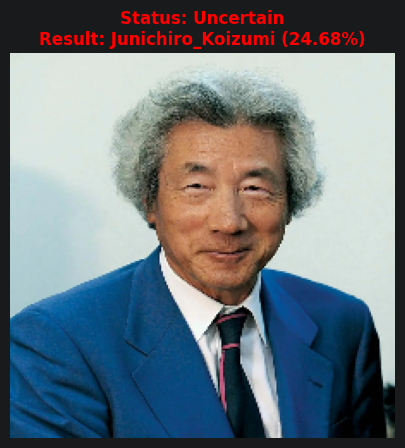


>>> THE WINNER IS: Junichiro_Koizumi (24.68%) <<<


In [3]:
import tensorflow as tf
import json

# 1. Load your saved model and JSON labels
model_path = 'ResNet50_lfw50/Checkpoints/PersonCNN_ResNet50_lfw50_FT_epoch_206_val_acc_0.8500.keras'
model = tf.keras.models.load_model(model_path)

json_path = 'classes.json'
with open(json_path, 'r') as f:
    class_names = json.load(f)['class_names']

if cropped_face is not None:
    # 2. Preprocess the crop specifically for ResNet50
    # Resize to the input size the model expects
    face_resized = cv2.resize(cropped_face, (224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(face_resized)
    img_array = np.expand_dims(img_array, axis=0)
    processed_img = tf.keras.applications.resnet50.preprocess_input(img_array)

    # 3. Make the prediction
    predictions = model.predict(processed_img)
    probabilities = predictions[0]
    predicted_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_index]
    confidence = probabilities[predicted_index] * 100

    # 4. Sorting results for the leaderboard
    results = sorted(zip(class_names, probabilities), key=lambda x: x[1], reverse=True)

    print(f"\n{'Name':<25} | {'Confidence':<10}")
    print("-" * 40)
    for name, prob in results:
        print(f"{name:25} | {prob*100:6.2f}%")

    # 5. Final Visual Feedback
    if confidence > 80:
        status, box_color = "Verified", 'green'
    elif confidence > 40:
        status, box_color = "Likely Match", 'orange'
    else:
        status, box_color = "Uncertain", 'red'

    plt.figure(figsize=(8, 5))
    plt.imshow(face_resized) # Show what the model actually "saw"
    plt.title(f"Status: {status}\nResult: {predicted_class} ({confidence:.2f}%)",
              color=box_color, fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

    print(f"\n>>> THE WINNER IS: {predicted_class} ({confidence:.2f}%) <<<")

In [4]:
def ensemble_prediction(img_path, zoom_factors=[0.1, 0.2, 0.3, 0.4]):
    all_votes = []
    
    print(f"Running Ensemble Prediction with {len(zoom_factors)} zoom levels...")

    for factor in zoom_factors:
        # 1. Get the crop for this specific zoom
        crop = get_face_crop_modern(img_path, zoom_out_factor=factor)

        if crop is not None:
            # 2. Preprocess & Predict
            face_resized = cv2.resize(crop, (224, 224))
            img_array = tf.keras.preprocessing.image.img_to_array(face_resized)
            img_array = np.expand_dims(img_array, axis=0)
            processed_img = tf.keras.applications.resnet50.preprocess_input(img_array)

            preds = model.predict(processed_img, verbose=0)
            winner_idx = np.argmax(preds[0])
            winner_name = class_names[winner_idx]

            all_votes.append(winner_name)
            print(f" > Zoom {int(factor*100)}%: Predicted {winner_name}")

    # 3. Final Result: The Most Frequent Winner (Majority Vote)
    from collections import Counter
    vote_counts = Counter(all_votes)
    final_winner, count = vote_counts.most_common(1)[0]

    print("\n--- FINAL ENSEMBLE RESULT ---")
    print(f"Winner: {final_winner} ({count}/{len(all_votes)} votes)")
    return final_winner